Lasso Regression:

**Y = wX + b**

Y --> Dependent Variable

X --> Independent Variable

w --> weight

b --> bias

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

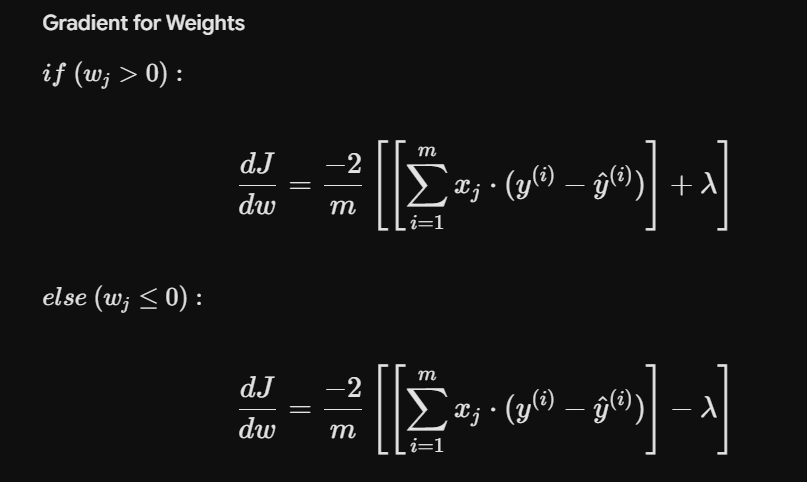

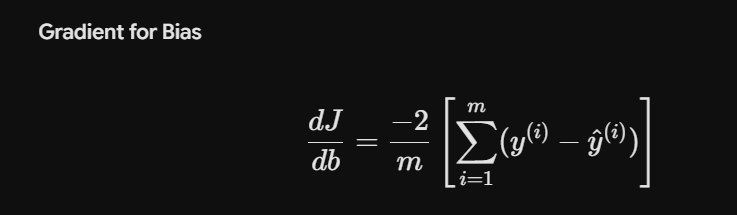

In [23]:
import numpy as np

In [24]:
import numpy as np

# Creating a class for Lasso Regression
class Lasso_Regression():

    # Initializing the hyperparameters
    def __init__(self, learning_rate, no_of_iterations, lambda_parameter):

        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations
        self.lambda_parameter = lambda_parameter

    # Fitting the dataset to the Lasso Regression model
    def fit(self, X, Y):

        # m --> Number of training examples
        # n --> Number of input features
        self.m, self.n = X.shape

        # Initializing weights and bias
        self.w = np.zeros(self.n)
        self.b = 0

        # Storing training data
        self.X = X
        self.Y = Y

        # Implementing Gradient Descent
        for i in range(self.no_of_iterations):
            self.update_weights()

    # Function for updating the weights and bias
    def update_weights(self):

        # Predicted values
        Y_prediction = self.predict(self.X)

        # Initializing gradients
        dw = np.zeros(self.n)

        # Calculating gradient for each weight
        for i in range(self.n):

            if self.w[i] > 0:
                dw[i] = (
                    -2 * (self.X[:, i].dot(self.Y - Y_prediction))
                    + self.lambda_parameter
                ) / self.m

            else:
                dw[i] = (
                    -2 * (self.X[:, i].dot(self.Y - Y_prediction))
                    - self.lambda_parameter
                ) / self.m

        # Gradient for bias
        db = -2 * np.sum(self.Y - Y_prediction) / self.m

        # Updating weights and bias
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    # Predicting target values
    def predict(self, X):

        Y_prediction = X.dot(self.w) + self.b

        return Y_prediction

In [25]:
# importing the dependencies
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics

In [26]:
# loading the data from csv file to a pandas dataframe

salary_data = pd.read_csv('E:/ML/salary_data (1).csv')

In [27]:
# printing the first 5 columns of the dataframe
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [28]:
features = salary_data.iloc[:,:-1].values      
target = salary_data.iloc[:,1].values

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(features, target, 
                                                    test_size=0.33, 
                                                    random_state = 2)

In [30]:
model = Lasso_Regression(learning_rate = 0.02, no_of_iterations=1000,
                         lambda_parameter=200)

In [33]:
model.fit(X_train, Y_train)
test_data_prediction = model.predict(X_test)
print(test_data_prediction)

[ 36068.90441536  34166.14804787  66513.00629512  58901.98082518
  91248.83907243  80783.67905126 101713.9990936   52242.33353898
  42728.55170156  88394.7045212 ]


In [34]:
from sklearn import metrics

# R squared error
score_1 = metrics.r2_score(Y_test, test_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_test, test_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.9041366551714738
Mean Absolute Error :  6675.382767802961


In [35]:
from sklearn.linear_model import Lasso
sk_model = Lasso()

In [36]:
sk_model.fit(X_train, Y_train)
sk_test_data_prediction = sk_model.predict(X_test)

In [37]:
# R squared error
score_1_ = metrics.r2_score(Y_test, sk_test_data_prediction)

# Mean Absolute Error
score_2_ = metrics.mean_absolute_error(Y_test, sk_test_data_prediction)

print("R squared error : ", score_1_)
print('Mean Absolute Error : ', score_2_)

R squared error :  0.9041817142395875
Mean Absolute Error :  6673.480440148538
